In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

total_time=15
# build forcing function from string
def create_time_function(expr):
    safe = {'__builtins__': None,
            'sin': math.sin, 'cos': math.cos,
            'exp': math.exp, 'sqrt': math.sqrt, 'pi': math.pi}
    return eval(f"lambda t: {expr}", safe)

# first-order ODE: a y' + b y = f(t)
def make_first_order_system(a, b, forcing_func):
    def system(t, y):
        return (forcing_func(t) - b*y[0]) / a
    return system

# taking inputs
a, b = map(float, input("Enter coefficients a (dy/dt), b (y): ").split())
forcing = create_time_function(input("Enter forcing function f(t): "))
y0 = [float(input("Enter initial condition y(0): "))]

# actual solution to compare with
t_span = (0, total_time)
t_eval = np.linspace(*t_span, 500)

system = make_first_order_system(a, b, forcing)
sol = solve_ivp(system, t_span, y0, t_eval=t_eval)
radius=max(sol.y[0])

In [7]:
import nengo
tau = 0.06  # synaptic time constant

with nengo.Network() as model:
    # The input signal u(t)
    stim = nengo.Node(forcing)

    # Represents the state y(t)
    state_ens = nengo.Ensemble(n_neurons=200, dimensions=1, radius=radius or 1)
    # state_ens(t+1) = state_ens(t)

    nengo.Connection(state_ens, state_ens, synapse=tau, transform=1)

    # Represents the prediction error: u(t) - b*y(t)
    error_ens = nengo.Ensemble(n_neurons=50, dimensions=1, radius=2)

    # predicitve coding

    # persistent problem - the output decoded signal always started with 0.
    # so we create the initialization node
    # This node will output y0 for the first few ms, then turn off.
    init_node = nengo.Node(lambda t: y0 if t < 0.02 else 0)
    #state_ens+=init_node
    nengo.Connection(init_node, state_ens, synapse=0.01)

    # error_ens = u(t)
    nengo.Connection(stim, error_ens, transform=1, synapse=None)

    # compute the prediction b*y(t) and subtract it from the error
    # error_ens-=b*state_ens
    nengo.Connection(state_ens, error_ens, transform=-b, synapse=None)

    # 3. Update the state by integrating the scaled error
    # The transform tau/a makes the dynamics match the ODE
    # state_ens+=error_ens*tau/a
    nengo.Connection(error_ens, state_ens, transform=tau/a, synapse=tau)


#so finally the equations are
#error_ens= u(t) - b * state_ens
#state_ens= init_node + error_ens*tau/a
#therefore, state_ens(t+1) = state_ens(t) + initial_pulse + tau/a * (u(t)-b*state_ens)
    # --- Probes ---
    state_probe = nengo.Probe(state_ens, synapse=0.01)
    error_probe = nengo.Probe(error_ens, synapse=0.01)

    # probe decoded state
    y_probe = nengo.Probe(state_ens, synapse=0.01)
    u_probe = nengo.Probe(stim)
    spike_probe = nengo.Probe(state_ens.neurons)

# run the simulation
with nengo.Simulator(model) as sim:
    sim.run(total_time)



Build finished in 0:00:01.                                                      
Simulation finished in 0:00:03.                                                 


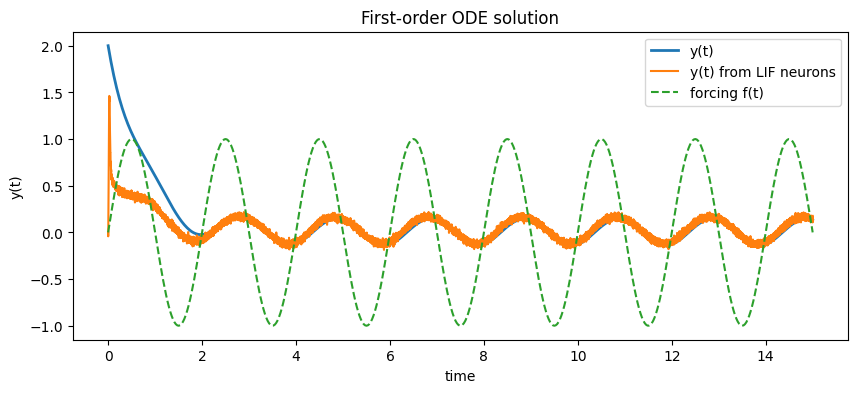

In [8]:
# plot results
plt.figure(figsize=(10,4))
plt.plot(sol.t, sol.y[0], label="y(t)", linewidth=2)
plt.plot(sim.trange(), sim.data[y_probe], label="y(t) from LIF neurons")
plt.plot(sol.t, [forcing(t) for t in sol.t], "--", label="forcing f(t)")

plt.xlabel("time")
plt.ylabel("y(t)")
plt.title("First-order ODE solution")
plt.legend()
plt.show()

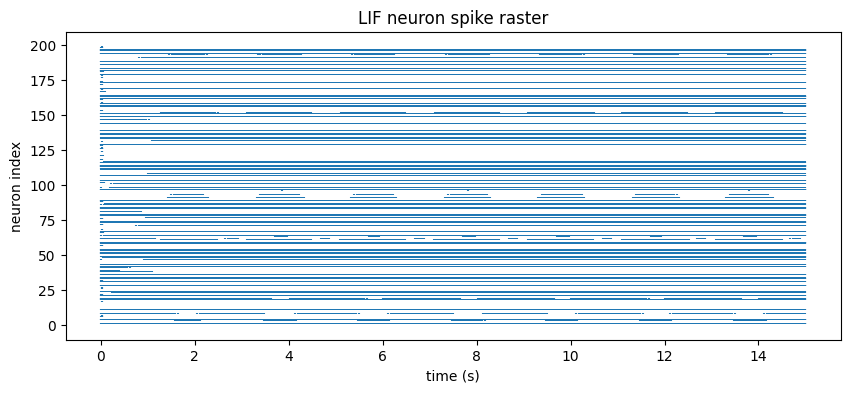

In [9]:
plt.figure(figsize=(10,4))
spikes = sim.data[spike_probe]
plt.eventplot(
    [sim.trange()[spikes[:,i] > 0] for i in range(spikes.shape[1])],
    linelengths=0.5
)

plt.xlabel("time (s)")
plt.ylabel("neuron index")
plt.title("LIF neuron spike raster")
plt.show()

Text(0.5, 0, 'Time (s)')

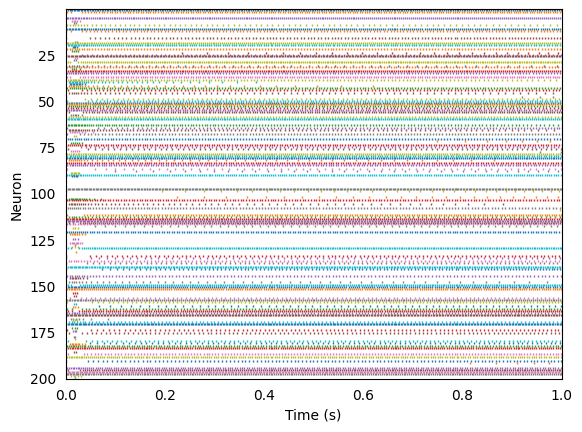

In [10]:
from nengo.utils.matplotlib import rasterplot
plt.figure()
ax = plt.subplot(1, 1, 1)
rasterplot(sim.trange(), sim.data[spike_probe], ax)
ax.set_xlim(0, 1)
ax.set_ylabel("Neuron")
ax.set_xlabel("Time (s)")
